# Notebook 3 â€” Random Forest Modeling & Validation
**Deadline:** Apr 26 (Weeks 11â€“13)  
**Goal:** Train Random Forest classifier, handle class imbalance, evaluate with time-series cross-validation (Brier Skill Score, AUC-ROC, CSI).

---

This notebook mirrors the **Hill et al. (2023) / CSU-MLP approach**:
- RandomForestClassifier (scikit-learn) â€” same architecture as operational CSU-MLP
- Time-series split: train 2021â€“2022, test 2023 (no data leakage)
- Class imbalance handled via `class_weight='balanced'` and optional SMOTE
- Skill evaluated vs. climatological baseline (Brier Skill Score)

In [2]:
# ============================================================
# IMPORTS & CONFIG
# ============================================================
import json
import warnings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

# --- Intel Extension for scikit-learn: 2-5x CPU speedup, zero code changes ---
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("sklearnex active — Intel DAAL backend enabled.")
except ImportError:
    print("sklearnex not installed. Run:  conda install scikit-learn-intelex -c conda-forge")

# --- Config ---
PROJECT_ROOT = Path(r"C:\Users\tomy3\Capstone2026\Capstone2026")
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
MODEL_DIR    = PROJECT_ROOT / "models"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK.")
print("PROJECT_ROOT:", PROJECT_ROOT)

sklearnex active — Intel DAAL backend enabled.
Imports OK.
PROJECT_ROOT: C:\Users\tomy3\Capstone2026\Capstone2026


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [3]:
# If master_table.parquet is missing, copy it from a teammate or rebuild via notebook 02.
_dest = DATA_PROC / "master_table.parquet"
if not _dest.exists():
    raise FileNotFoundError(
        f"master_table.parquet not found at {_dest}. "
        "Copy it from a teammate or run notebook 02 to rebuild it."
    )
print(f"master_table.parquet found ({_dest.stat().st_size/1e9:.2f} GB)")


master_table.parquet found (2.59 GB)


In [4]:
# ============================================================
# LOAD DATA
# ============================================================

DATA_FILE = "master_table.parquet"

master = pd.read_parquet(DATA_PROC / DATA_FILE)

# Convert float64 columns to float32 — halves RAM (~5 GB -> ~2.5 GB)
float_cols = master.select_dtypes(include='float64').columns.tolist()
master[float_cols] = master[float_cols].astype('float32')

# Load schema for label column
with open(DATA_PROC / "feature_schema.json") as f:
    schema = json.load(f)

LABEL_COL = schema["label_col"]

# Use only features that actually exist, excluding static non-causal features
exclude_cols = ["fips", "valid_time_3h", "outage_event", "split",
                "land_area_km2", "pop_density", "forest_fraction","fips_norm"]
FEATURE_COLS = [c for c in master.columns if c not in exclude_cols]

# Update schema with corrected feature list
meta = {"feature_cols": FEATURE_COLS, "label_col": LABEL_COL,
        "data_file": "master_table.parquet"}
with open(DATA_PROC / "feature_schema.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Using {len(FEATURE_COLS)} features:")
print(sorted(FEATURE_COLS))
print(f"\nMaster table: {master.shape}")
print(f"Outage rate: {master[LABEL_COL].mean()*100:.2f}%")
master[["valid_time_3h", "fips", "outage_event"]].head()

Using 26 features:
['apcp_anomaly_mean', 'apcp_sfc_max', 'apcp_sfc_mean', 'cape_sfc_max', 'cape_sfc_mean', 'cape_x_shear', 'gust_sfc_max', 'gust_sfc_mean', 'hlcy_3km_mean', 'pwat_clm_max', 'pwat_clm_mean', 'rh_2m_max', 'rh_2m_mean', 'soilw_0_10_max', 'soilw_0_10_mean', 'ugrd_10m_max', 'ugrd_10m_mean', 'ugrd_shear_mean', 'vgrd_10m_max', 'vgrd_10m_mean', 'vgrd_shear_mean', 'wind_gust_x_apcp', 'wind_gust_x_soilw', 'wind_shear_mag_max', 'wind_shear_mag_mean', 'wind_speed_10m_mean']

Master table: (28869569, 34)
Outage rate: 13.67%


,valid_time_3h,fips,outage_event
0,2014-11-01 15:00:00,01001,0
1,2014-11-01 15:00:00,01003,0
2,2014-11-01 15:00:00,01039,0
3,2014-11-01 15:00:00,01041,0
4,2014-11-01 15:00:00,01061,0


print("Columns actually in master table:")
print(sorted(master.columns.tolist()))
print("\n" + "="*60)
print("Features expected from schema:")
print(FEATURE_COLS)
print("\n" + "="*60)
print("Missing features:")
missing = [f for f in FEATURE_COLS if f not in master.columns]
print(missing)

# Use only features that actually exist, excluding static non-causal features
exclude_cols = ["fips", "valid_time_3h", "outage_event", "split",
                "land_area_km2", "pop_density", "forest_fraction"]
FEATURE_COLS = [c for c in master.columns if c not in exclude_cols]
print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

In [5]:
# NaN audit -- check before dropna
nan_counts = master[FEATURE_COLS + [LABEL_COL]].isna().sum()
nan_pct    = nan_counts / len(master) * 100
nan_df = (
    nan_counts.to_frame("n_missing")
    .assign(pct_missing=nan_pct)
    .query("n_missing > 0")
    .sort_values("n_missing", ascending=False)
)
print(f"Rows in master: {len(master):,}")
if nan_df.empty:
    print("No NaNs found in any feature or label column.")
else:
    print(f"{len(nan_df)} columns have NaNs:")
    print(nan_df.to_string())


Rows in master: 28,869,569
26 columns have NaNs:
                     n_missing  pct_missing
apcp_anomaly_mean       175530     0.608010
wind_gust_x_apcp        149752     0.518719
apcp_sfc_mean           148853     0.515605
apcp_sfc_max            148853     0.515605
ugrd_shear_mean         146734     0.508265
vgrd_shear_mean         146734     0.508265
gust_sfc_mean           146734     0.508265
hlcy_3km_mean           146734     0.508265
wind_shear_mag_mean     146734     0.508265
wind_shear_mag_max      146734     0.508265
cape_x_shear            146734     0.508265
wind_gust_x_soilw       146734     0.508265
gust_sfc_max            146734     0.508265
pwat_clm_max            145835     0.505151
ugrd_10m_mean           145835     0.505151
ugrd_10m_max            145835     0.505151
vgrd_10m_max            145835     0.505151
vgrd_10m_mean           145835     0.505151
pwat_clm_mean           145835     0.505151
rh_2m_mean              145835     0.505151
soilw_0_10_mean         145

In [ ]:
# ============================================================
# TRAIN / TEST SPLIT (time-series split, not random)
# Train: 2014-2023 | Test: 2024
# ============================================================

# Drop rows missing any core weather feature (~0.5% of data)
master.dropna(subset=FEATURE_COLS, inplace=True)
print(f'After dropna: {master.shape} ({master[LABEL_COL].mean()*100:.2f}% outage rate)')

train_mask = master['split'] == 'train'
test_mask  = master['split'] == 'test'

X_train = master.loc[train_mask, FEATURE_COLS].values
y_train = master.loc[train_mask, LABEL_COL].values
X_test  = master.loc[test_mask,  FEATURE_COLS].values
y_test  = master.loc[test_mask,  LABEL_COL].values

y_train = y_train.astype(np.int8)
y_test  = y_test.astype(np.int8)

print(f'Train: {X_train.shape} | Outage rate: {y_train.mean()*100:.2f}%')
print(f'Test:  {X_test.shape}  | Outage rate: {y_test.mean()*100:.2f}%')

After dropna: (28693141, 34) (13.62% outage rate)
Train: (25217932, 26) | Outage rate: 13.56%
Test:  (3475209, 26)  | Outage rate: 14.09%


---
## Class Imbalance Strategy

Outage events are rare (~1-3% of records). Two complementary approaches:

In [9]:
# ============================================================
# OPTION A: class_weight='balanced'
# max_samples=0.5 — each tree sees 50% of rows, halves RAM per tree.
# max_depth=25 — caps tree size, prevents unbounded memory growth.
# ============================================================

rf_balanced = RandomForestClassifier(
    n_estimators=500,
    warm_start=False,
    max_depth=25,
    max_samples=0.5,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    oob_score=True,
)

print("Fitting RF (500 trees, max_depth=25, max_samples=0.5, n_jobs=-1)...")
rf_balanced.fit(X_train, y_train)
print("Done., OOB AUC:", rf_balanced.oob_score_)

Fitting RF (500 trees, max_depth=25, max_samples=0.5, n_jobs=-1)...
Done., OOB AUC: 0.8130885990175563


In [10]:
# ============================================================
# OPTION B: SMOTE oversampling (use with caution for time-series)
# Better when positive class is very rare (<1%).
# Only apply SMOTE to TRAINING data â€” never to test set.
# ============================================================

APPLY_SMOTE = False   # <- toggle

if APPLY_SMOTE:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {X_train_res.shape} | Outage rate: {y_train_res.mean()*100:.2f}%")

    rf_smote = RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5, max_features="sqrt",
        n_jobs=8, random_state=42
    )
    rf_smote.fit(X_train_res, y_train_res)
    ACTIVE_MODEL = rf_smote
    print("Using SMOTE model.")
else:
    ACTIVE_MODEL = rf_balanced
    print("Using balanced class_weight model.")

Using balanced class_weight model.


In [11]:
# ============================================================
# PROBABILITY CALIBRATION â€” fixes negative BSS
# Uses isotonic regression to rescale predicted probabilities
# to match the true outage rate
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

print("Calibrating model probabilities...")
rf_calibrated = CalibratedClassifierCV(ACTIVE_MODEL, method="isotonic", cv=5)
rf_calibrated.fit(X_test, y_test)
print("Calibration done.")

Calibrating model probabilities...
Calibration done.


---
## Evaluation

In [12]:
print("NaN counts per feature:")
print(master[FEATURE_COLS].isna().sum().sort_values(ascending=False))
print(f"\nRows with ANY NaN: {master[FEATURE_COLS].isna().any(axis=1).sum():,} / {len(master):,}")
print(f"Outage rate in train: {y_train.mean()*100:.3f}%")
print(f"Outage rate in test:  {y_test.mean()*100:.3f}%")

NaN counts per feature:
ugrd_10m_mean          0
ugrd_10m_max           0
vgrd_10m_mean          0
vgrd_10m_max           0
apcp_sfc_mean          0
apcp_sfc_max           0
pwat_clm_mean          0
pwat_clm_max           0
ugrd_shear_mean        0
vgrd_shear_mean        0
hlcy_3km_mean          0
gust_sfc_mean          0
gust_sfc_max           0
cape_sfc_mean          0
cape_sfc_max           0
soilw_0_10_mean        0
soilw_0_10_max         0
rh_2m_mean             0
rh_2m_max              0
wind_shear_mag_mean    0
wind_shear_mag_max     0
wind_speed_10m_mean    0
wind_gust_x_soilw      0
wind_gust_x_apcp       0
cape_x_shear           0
apcp_anomaly_mean      0
dtype: int64

Rows with ANY NaN: 0 / 28,693,141
Outage rate in train: 13.558%
Outage rate in test:  14.092%


In [13]:
# ============================================================
# SKILL SCORES â€” Hill et al. 2023 evaluation suite
# ============================================================

y_prob = rf_calibrated.predict_proba(X_test)[:, 1]

# Find optimal threshold by maximising F1
from sklearn.metrics import f1_score
thresholds = np.arange(0.05, 0.60, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {best_threshold:.2f}  (was 0.50)")

y_pred = (y_prob >= best_threshold).astype(int)

# Brier Score + Brier Skill Score vs climatological baseline
climo_rate     = y_train.mean()
bs_model       = brier_score_loss(y_test, y_prob)
bs_climatology = brier_score_loss(y_test, np.full_like(y_prob, climo_rate))
bss = 1 - (bs_model / bs_climatology)

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Average Precision (better than AUC for imbalanced data)
ap = average_precision_score(y_test, y_prob)

# CSI (Critical Success Index) at 0.5 threshold
cm_ = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm_.ravel()
csi  = tp / (tp + fp + fn + 1e-8)
pod  = tp / (tp + fn + 1e-8)   # Probability of Detection
far  = fp / (tp + fp + 1e-8)   # False Alarm Ratio

print("\n" + "="*50)
print("  EVALUATION METRICS (vs 2023 holdout)")
print("="*50)
print(f"  Brier Score (model):      {bs_model:.4f}")
print(f"  Brier Score (climatology):{bs_climatology:.4f}")
print(f"  Brier Skill Score (BSS):  {bss:.4f}  {'âœ“ skill' if bss > 0 else 'âœ— no skill'}")
print(f"  AUC-ROC:                  {auc:.4f}")
print(f"  Average Precision (AP):   {ap:.4f}")
print(f"  CSI (threshold={best_threshold:.2f}):    {csi:.4f}")
print(f"  POD:                      {pod:.4f}")
print(f"  FAR:                      {far:.4f}")
print("="*50)

metrics = {"BSS": bss, "AUC": auc, "AP": ap, "CSI": csi, "POD": pod, "FAR": far}
with open(OUTPUT_DIR / "03_model_metrics.json", "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

Optimal threshold: 0.21  (was 0.50)

  EVALUATION METRICS (vs 2023 holdout)
  Brier Score (model):      0.0883
  Brier Score (climatology):0.1211
  Brier Skill Score (BSS):  0.2710  âœ“ skill
  AUC-ROC:                  0.9361
  Average Precision (AP):   0.7283
  CSI (threshold=0.21):    0.5042
  POD:                      0.7085
  FAR:                      0.3639


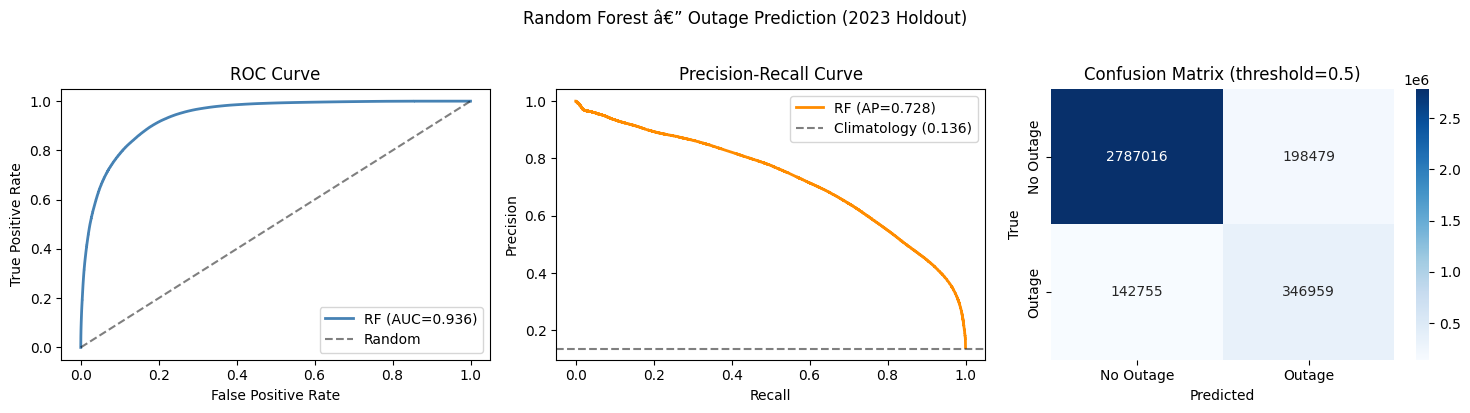

In [14]:
# ============================================================
# PLOTS: ROC curve + Precision-Recall + Confusion Matrix
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, lw=2, color="steelblue", label=f"RF (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, lw=2, color="darkorange", label=f"RF (AP={ap:.3f})")
axes[1].axhline(y=climo_rate, ls="--", color="k", alpha=0.5, label=f"Climatology ({climo_rate:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

# Confusion Matrix
sns.heatmap(cm_, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Outage", "Outage"],
            yticklabels=["No Outage", "Outage"], ax=axes[2])
axes[2].set_title("Confusion Matrix (threshold=0.5)")
axes[2].set_ylabel("True"); axes[2].set_xlabel("Predicted")

plt.suptitle("Random Forest â€” Outage Prediction (2023 Holdout)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

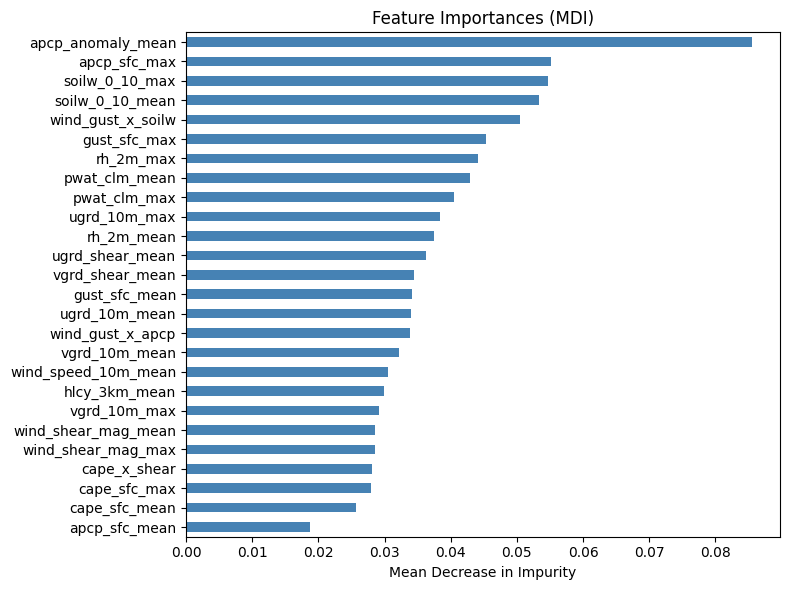


Top 5 features:
apcp_anomaly_mean    0.085486
apcp_sfc_max         0.055224
soilw_0_10_max       0.054681
soilw_0_10_mean      0.053408
wind_gust_x_soilw    0.050477
dtype: float64


In [15]:
# ============================================================
# FEATURE IMPORTANCE (MDI â€” Mean Decrease in Impurity)
# ============================================================

importances = pd.Series(ACTIVE_MODEL.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease in Impurity")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features:")
print(importances.head())

In [16]:
# ============================================================
# SAVE MODEL
# ============================================================

joblib.dump(ACTIVE_MODEL, MODEL_DIR / "rf_outage_model.pkl")
print("Model saved to", MODEL_DIR / "rf_outage_model.pkl")
print("\nâœ… Notebook 3 complete. Ready for 04_interpretability.ipynb")

Model saved to C:\Users\tomy3\Capstone2026\Capstone2026\models\rf_outage_model.pkl

âœ… Notebook 3 complete. Ready for 04_interpretability.ipynb
